# Data Compression and Coding Project

**Topic:** Data Coding Theory and Compression  
**Language:** Python  
**Deliverables:** Huffman, entropy analysis, LZW, adaptive Huffman, RLE, tests, and visual comparisons.

## Part 1 — Setup

Imports, paths, and reproducible output folders.

In [43]:
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, field
from itertools import count
from typing import Dict, Hashable, Iterable, List, Mapping, Optional, Sequence, Tuple, TypeVar
import gzip
import heapq
import math
import struct
import sys
import time
import zlib

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Python: {sys.version.split()[0]}")
print(f"Project root: {ROOT}")

Python: 3.12.0
Project root: d:\pama\projectHadis\data_compression_huffman_project


## Part 2 — Static Huffman Coding

Frequency table, tree construction, code generation, encoding, decoding, and file serialization.

In [44]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass, field
from itertools import count
import heapq
import math
import struct
from typing import Dict, Hashable, Iterable, List, Mapping, Optional, Sequence, Tuple, TypeVar

Symbol = TypeVar("Symbol", bound=Hashable)
HUFFMAN_MAGIC = b"HUF1"


@dataclass(order=True)
class HuffmanNode:
    frequency: int
    order: int
    symbol: Optional[Hashable] = field(default=None, compare=False)
    left: Optional["HuffmanNode"] = field(default=None, compare=False)
    right: Optional["HuffmanNode"] = field(default=None, compare=False)

    @property
    def is_leaf(self) -> bool:
        return self.left is None and self.right is None


def frequency_table(data: Iterable[Symbol]) -> Dict[Symbol, int]:
    return dict(Counter(data))


def build_huffman_tree(frequencies: Mapping[Symbol, int]) -> Optional[HuffmanNode]:
    if not frequencies:
        return None

    serial = count()
    heap: List[HuffmanNode] = []
    for symbol, frequency in sorted(frequencies.items(), key=lambda item: repr(item[0])):
        if frequency <= 0:
            raise ValueError("All frequencies must be positive.")
        heapq.heappush(
            heap,
            HuffmanNode(
                frequency=int(frequency),
                order=next(serial),
                symbol=symbol,
            ),
        )

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        parent = HuffmanNode(
            frequency=left.frequency + right.frequency,
            order=next(serial),
            left=left,
            right=right,
        )
        heapq.heappush(heap, parent)

    return heap[0]


def generate_codes(root: Optional[HuffmanNode]) -> Dict[Symbol, str]:
    if root is None:
        return {}

    codes: Dict[Symbol, str] = {}

    def visit(node: HuffmanNode, prefix: str) -> None:
        if node.is_leaf:
            codes[node.symbol] = prefix or "0"
            return
        if node.left is not None:
            visit(node.left, prefix + "0")
        if node.right is not None:
            visit(node.right, prefix + "1")

    visit(root, "")
    return codes


def encode_symbols(data: Sequence[Symbol], codes: Mapping[Symbol, str]) -> str:
    try:
        return "".join(codes[symbol] for symbol in data)
    except KeyError as exc:
        raise ValueError(f"Missing Huffman code for symbol: {exc.args[0]!r}") from exc


def decode_bits(
    bits: str,
    root: Optional[HuffmanNode],
    expected_length: Optional[int] = None,
) -> List[Symbol]:
    if root is None:
        if bits or (expected_length not in (None, 0)):
            raise ValueError("A non-empty stream cannot be decoded without a tree.")
        return []

    if root.is_leaf:
        length = expected_length if expected_length is not None else len(bits)
        if expected_length is not None and len(bits) < expected_length:
            raise ValueError("Truncated single-symbol Huffman bit stream.")
        if length < 0:
            raise ValueError("Expected length cannot be negative.")
        if bits and any(bit != "0" for bit in bits[:length]):
            raise ValueError("Invalid bit for a single-symbol Huffman tree.")
        return [root.symbol] * length

    result: List[Symbol] = []
    node = root
    for bit in bits:
        if bit == "0":
            node = node.left
        elif bit == "1":
            node = node.right
        else:
            raise ValueError("Bit stream must contain only '0' and '1'.")

        if node is None:
            raise ValueError("Invalid Huffman bit stream.")

        if node.is_leaf:
            result.append(node.symbol)
            if expected_length is not None and len(result) == expected_length:
                return result
            node = root

    if node is not root:
        raise ValueError("Truncated Huffman bit stream.")
    if expected_length is not None and len(result) != expected_length:
        raise ValueError("Decoded length does not match the expected length.")
    return result


def shannon_entropy(frequencies: Mapping[Hashable, int]) -> float:
    total = sum(frequencies.values())
    if total == 0:
        return 0.0
    return -sum(
        (frequency / total) * math.log2(frequency / total)
        for frequency in frequencies.values()
        if frequency > 0
    )


def average_code_length(
    frequencies: Mapping[Symbol, int],
    codes: Mapping[Symbol, str],
) -> float:
    total = sum(frequencies.values())
    if total == 0:
        return 0.0
    return sum(frequencies[symbol] * len(codes[symbol]) for symbol in frequencies) / total


def is_prefix_free(codes: Mapping[Hashable, str]) -> bool:
    values = list(codes.values())
    return all(
        not other.startswith(code)
        for i, code in enumerate(values)
        for j, other in enumerate(values)
        if i != j
    )


def kraft_sum(codes: Mapping[Hashable, str]) -> float:
    return sum(2.0 ** (-len(code)) for code in codes.values())


def bits_to_bytes(bits: str) -> bytes:
    if not bits:
        return b""
    padding = (-len(bits)) % 8
    padded = bits + ("0" * padding)
    return bytes(int(padded[i:i + 8], 2) for i in range(0, len(padded), 8))


def bytes_to_bits(payload: bytes, bit_length: int) -> str:
    if bit_length < 0 or bit_length > len(payload) * 8:
        raise ValueError("Invalid bit length.")
    return "".join(f"{byte:08b}" for byte in payload)[:bit_length]


def compress_bytes(data: bytes) -> bytes:
    frequencies = frequency_table(data)
    root = build_huffman_tree(frequencies)
    codes = generate_codes(root)
    bits = encode_symbols(list(data), codes)
    payload = bits_to_bytes(bits)

    header = bytearray(HUFFMAN_MAGIC)
    header.extend(struct.pack(">QH", len(data), len(frequencies)))
    for symbol, frequency in sorted(frequencies.items()):
        header.extend(struct.pack(">BQ", int(symbol), int(frequency)))
    header.extend(struct.pack(">Q", len(bits)))
    return bytes(header) + payload


def decompress_bytes(blob: bytes) -> bytes:
    if len(blob) < 22 or blob[:4] != HUFFMAN_MAGIC:
        raise ValueError("Invalid Huffman file.")

    offset = 4
    original_size, symbol_count = struct.unpack_from(">QH", blob, offset)
    offset += 10

    frequencies: Dict[int, int] = {}
    for _ in range(symbol_count):
        if offset + 9 > len(blob):
            raise ValueError("Truncated Huffman header.")
        symbol, frequency = struct.unpack_from(">BQ", blob, offset)
        offset += 9
        frequencies[symbol] = frequency

    if offset + 8 > len(blob):
        raise ValueError("Missing Huffman bit length.")
    bit_length = struct.unpack_from(">Q", blob, offset)[0]
    offset += 8

    payload = blob[offset:]
    bits = bytes_to_bits(payload, bit_length)
    root = build_huffman_tree(frequencies)
    decoded = decode_bits(bits, root, expected_length=original_size)
    result = bytes(decoded)

    if len(result) != original_size:
        raise ValueError("Huffman output size mismatch.")
    return result

## Part 3 — Huffman Round-Trip Verification

A compact correctness check on text and edge cases.

In [45]:
huffman_cases = [
    b"",
    b"A",
    b"A" * 1000,
    b"ABRACADABRA",
    bytes(range(256)),
]

for case in huffman_cases:
    packed = compress_bytes(case)
    restored = decompress_bytes(packed)
    assert restored == case

demo_text = "HUFFMAN CODING MAKES FREQUENT SYMBOLS SHORT".encode("utf-8")
demo_frequencies = frequency_table(demo_text)
demo_tree = build_huffman_tree(demo_frequencies)
demo_codes = generate_codes(demo_tree)
demo_bits = encode_symbols(list(demo_text), demo_codes)
demo_restored = bytes(decode_bits(demo_bits, demo_tree, expected_length=len(demo_text)))

assert demo_restored == demo_text
assert is_prefix_free(demo_codes)

print("All static Huffman round-trip checks passed.")
print(f"Prefix-free: {is_prefix_free(demo_codes)}")
print(f"Kraft sum: {kraft_sum(demo_codes):.6f}")

All static Huffman round-trip checks passed.
Prefix-free: True
Kraft sum: 1.000000


## Part 4 — Entropy and Huffman Optimality

For probabilities \(p_i\), Shannon entropy is \(H=-\sum_i p_i\log_2 p_i\).  
A binary Huffman tree is optimal among prefix codes because each greedy merge combines the two least-probable sibling leaves, reducing the problem to a smaller optimal prefix-code problem. Repeating the exchange-and-reduction argument proves minimum weighted path length. Therefore the average length satisfies:

\[
H \leq L_{\text{Huffman}} < H+1
\]

In [46]:
text_files = {
    "English": DATA_DIR / "english_sample.txt",
    "Persian": DATA_DIR / "persian_sample.txt",
}

entropy_rows = []
for language, path in text_files.items():
    data = path.read_bytes()
    frequencies = frequency_table(data)
    tree = build_huffman_tree(frequencies)
    codes = generate_codes(tree)
    entropy = shannon_entropy(frequencies)
    average_length = average_code_length(frequencies, codes)

    entropy_rows.append({
        "Language": language,
        "Bytes": len(data),
        "Distinct byte values": len(frequencies),
        "Entropy H (bits/byte)": entropy,
        "Average Huffman length L": average_length,
        "H <= L": entropy <= average_length + 1e-12,
        "L < H + 1": average_length < entropy + 1.0 + 1e-12,
        "Prefix-free": is_prefix_free(codes),
        "Kraft sum": kraft_sum(codes),
    })

entropy_df = pd.DataFrame(entropy_rows)
display(entropy_df.round(6))
entropy_df.to_csv(RESULTS_DIR / "entropy_and_code_length.csv", index=False)

,Language,Bytes,Distinct byte values,Entropy H (bits/byte),Average Huffman length L,H <= L,L < H + 1,Prefix-free,Kraft sum
0,English,33119,44,4.381033,4.400556,True,True,True,1.0
1,Persian,51119,46,4.099973,4.124670,True,True,True,1.0


## Part 5B — Step-by-Step Huffman Tree Construction

This section visualizes the Huffman tree construction process from the initial frequency nodes to the final Huffman tree. Each step shows the two minimum-frequency nodes selected for merging.

In [47]:
from itertools import count
from pathlib import Path
from PIL import Image as PILImage
from IPython.display import display, Image as IPythonImage

import heapq
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd


def build_huffman_tree_with_steps(frequencies):
    """
    Build a Huffman tree and save the state of the forest
    after every merge operation.
    """

    if not frequencies:
        return None, []

    serial = count()
    heap = []

    # Create the initial leaf nodes
    for symbol, frequency in sorted(
        frequencies.items(),
        key=lambda item: repr(item[0])
    ):
        node = HuffmanNode(
            frequency=int(frequency),
            order=next(serial),
            symbol=symbol,
        )

        heapq.heappush(heap, node)

    steps = [
        {
            "step": 0,
            "title": "Step 0 - Initial frequency nodes",
            "roots": list(sorted(heap)),
            "left": None,
            "right": None,
            "parent": None,
        }
    ]

    step_number = 1

    # Merge the two minimum-frequency nodes at every step
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)

        parent = HuffmanNode(
            frequency=left.frequency + right.frequency,
            order=next(serial),
            left=left,
            right=right,
        )

        heapq.heappush(heap, parent)

        def node_description(node):
            if node.is_leaf:
                return repr(node.symbol)

            return f"Internal Node {node.frequency}"

        step_title = (
            f"Step {step_number} - Merge "
            f"{node_description(left)} ({left.frequency}) and "
            f"{node_description(right)} ({right.frequency}) "
            f"to create node {parent.frequency}"
        )

        steps.append(
            {
                "step": step_number,
                "title": step_title,
                "roots": list(sorted(heap)),
                "left": left,
                "right": right,
                "parent": parent,
            }
        )

        step_number += 1

    return heap[0], steps

## Part 5C — Positioning the Huffman Forest

This function calculates the position of every node in the current Huffman forest.

In [48]:
def forest_positions(roots, tree_gap=2.5):
    """
    Calculate positions for all trees that currently exist
    in the Huffman forest.
    """

    positions = {}
    next_x = [0.0]

    def walk(node, depth):
        if node.is_leaf:
            x_position = next_x[0]
            next_x[0] += 1.0

        else:
            children_x = []

            if node.left is not None:
                walk(node.left, depth + 1)
                children_x.append(
                    positions[id(node.left)][0]
                )

            if node.right is not None:
                walk(node.right, depth + 1)
                children_x.append(
                    positions[id(node.right)][0]
                )

            x_position = sum(children_x) / len(children_x)

        positions[id(node)] = (
            x_position,
            -depth
        )

    for tree_index, root in enumerate(roots):
        if tree_index > 0:
            next_x[0] += tree_gap

        walk(root, 0)

    return positions

## Part 5D — Drawing Each Huffman Construction Step

Each figure displays the current Huffman forest, including edge labels 0 and 1.

In [49]:
def draw_huffman_forest(
    roots,
    title,
    output_path,
    selected_nodes=None,
):
    """
    Draw the current Huffman forest and save it as a PNG file.
    """

    graph = nx.DiGraph()
    labels = {}
    edge_labels = {}

    selected_nodes = selected_nodes or set()

    def add_node_to_graph(node):
        node_id = id(node)

        # Important for drawing isolated leaf nodes
        graph.add_node(node_id)

        if node.is_leaf:
            if node.symbol == " ":
                symbol_label = "SPACE"
            elif node.symbol == "\n":
                symbol_label = "\\n"
            else:
                symbol_label = str(node.symbol)

            labels[node_id] = (
                f"{symbol_label}\n"
                f"Frequency = {node.frequency}"
            )

        else:
            labels[node_id] = (
                f"Internal\n"
                f"Frequency = {node.frequency}"
            )

        if node.left is not None:
            left_id = id(node.left)

            graph.add_edge(
                node_id,
                left_id
            )

            edge_labels[
                (node_id, left_id)
            ] = "0"

            add_node_to_graph(node.left)

        if node.right is not None:
            right_id = id(node.right)

            graph.add_edge(
                node_id,
                right_id
            )

            edge_labels[
                (node_id, right_id)
            ] = "1"

            add_node_to_graph(node.right)

    for root in roots:
        add_node_to_graph(root)

    positions = forest_positions(
        roots,
        tree_gap=2.5
    )

    node_sizes = []

    for node_id in graph.nodes:
        if node_id in selected_nodes:
            node_sizes.append(3000)
        else:
            node_sizes.append(2300)

    plt.figure(figsize=(15, 8))

    nx.draw(
        graph,
        positions,
        labels=labels,
        with_labels=True,
        node_size=node_sizes,
        font_size=8,
        font_weight="bold",
        arrows=False,
    )

    nx.draw_networkx_edge_labels(
        graph,
        positions,
        edge_labels=edge_labels,
        font_size=11,
        font_weight="bold",
    )

    plt.title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    plt.margins(0.15)
    plt.tight_layout()

    # Fixed image dimensions are suitable for GIF creation
    plt.savefig(
        output_path,
        dpi=180,
    )

    plt.show()
    plt.close()

## Part 5E — Generate All Huffman Construction Figures

The following code creates one image for every merge step and generates an animated GIF of the complete construction process.

Input text:
BANANABBCCCBBANDANA

Frequency table:


,Symbol,Frequency
0,D,1
1,C,3
2,N,4
3,B,5
4,A,6


C:\Users\Dolphin_Computer\AppData\Local\Temp\ipykernel_12692\1658437610.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


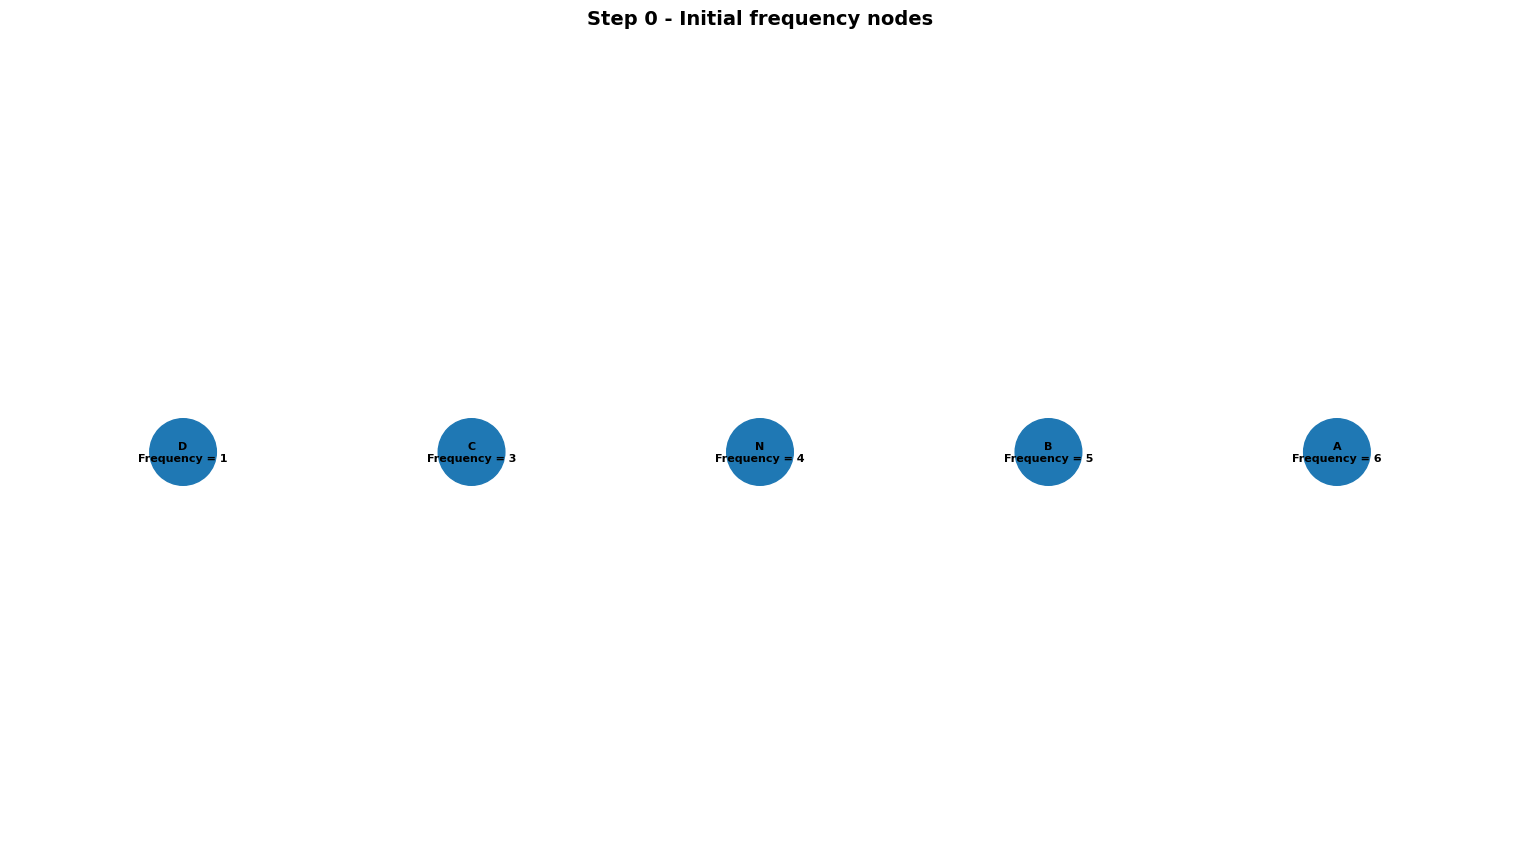

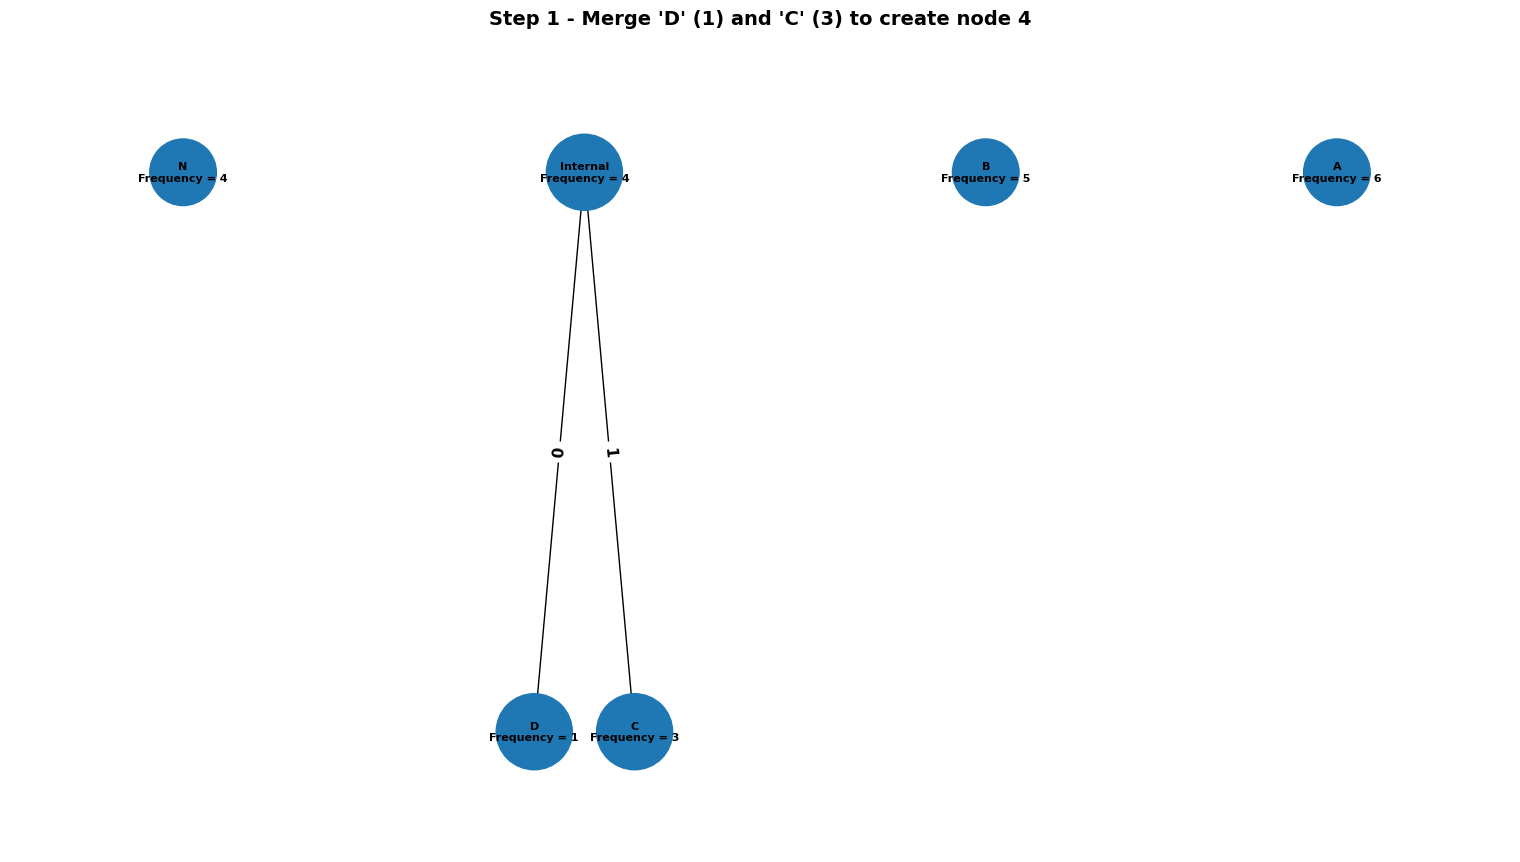

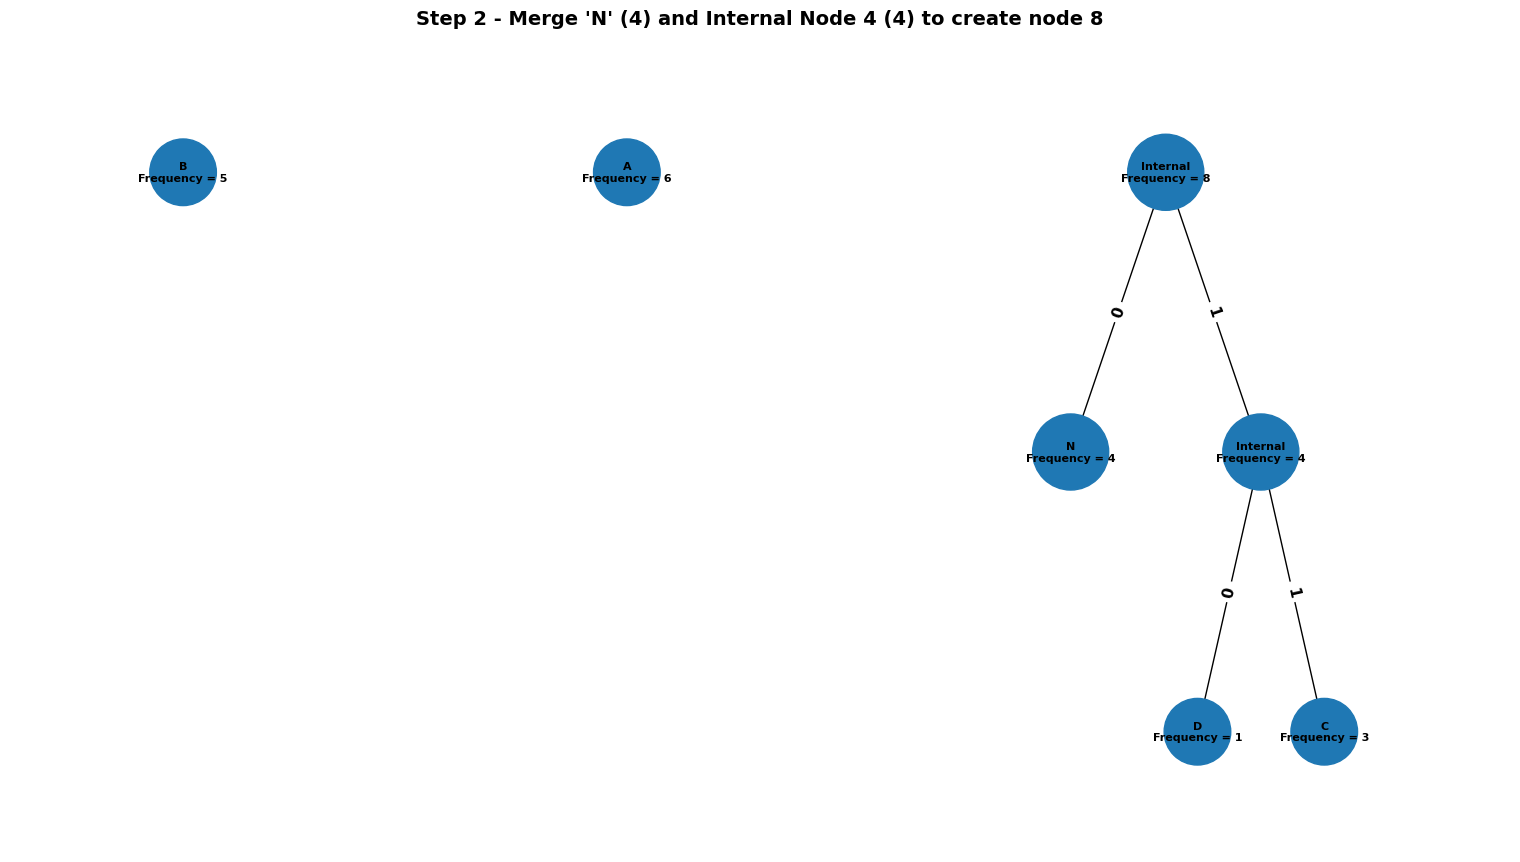

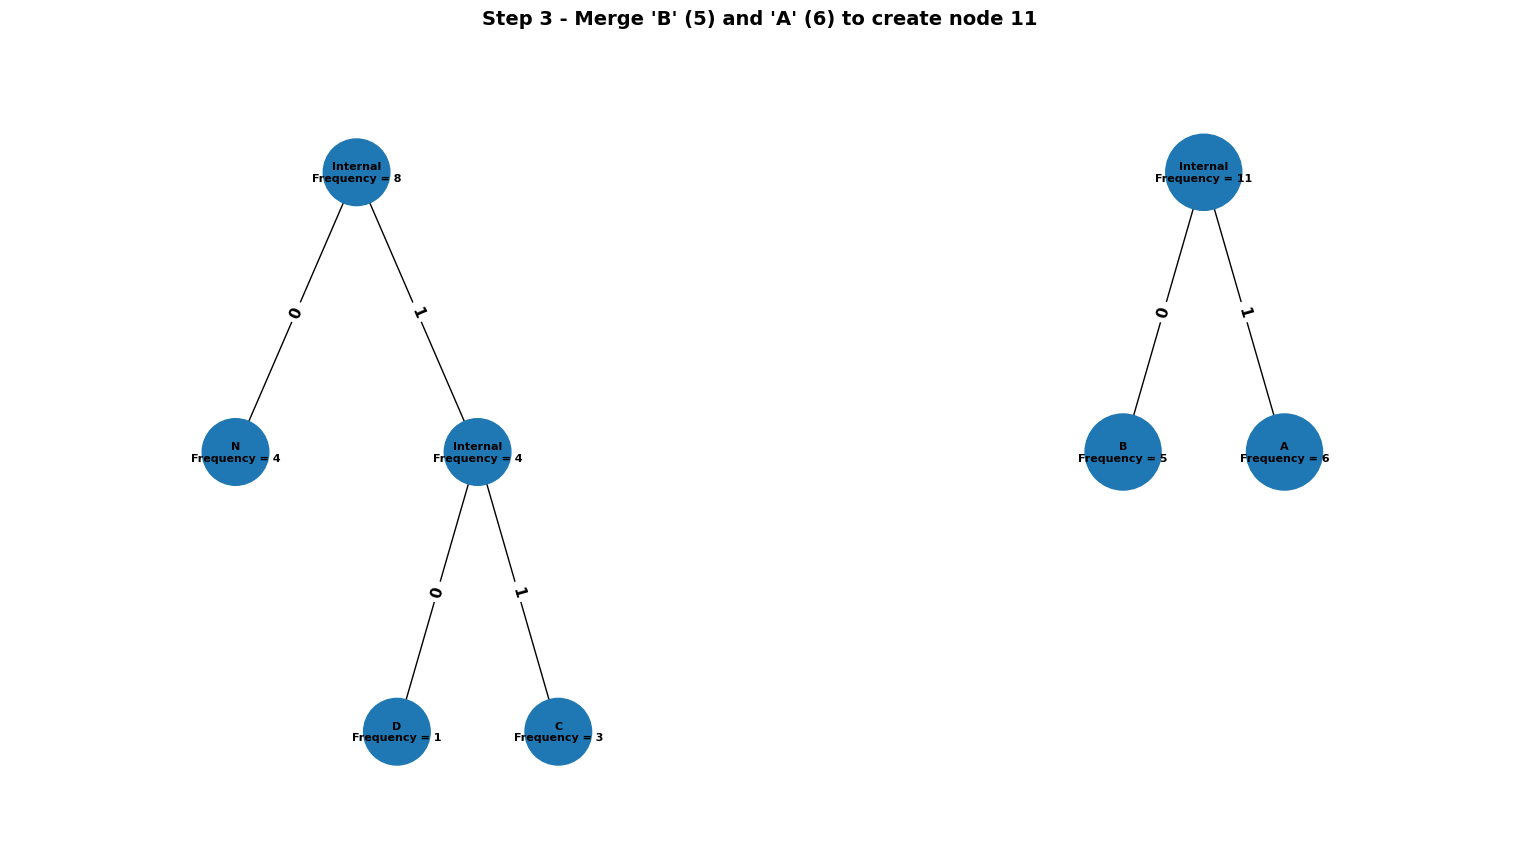

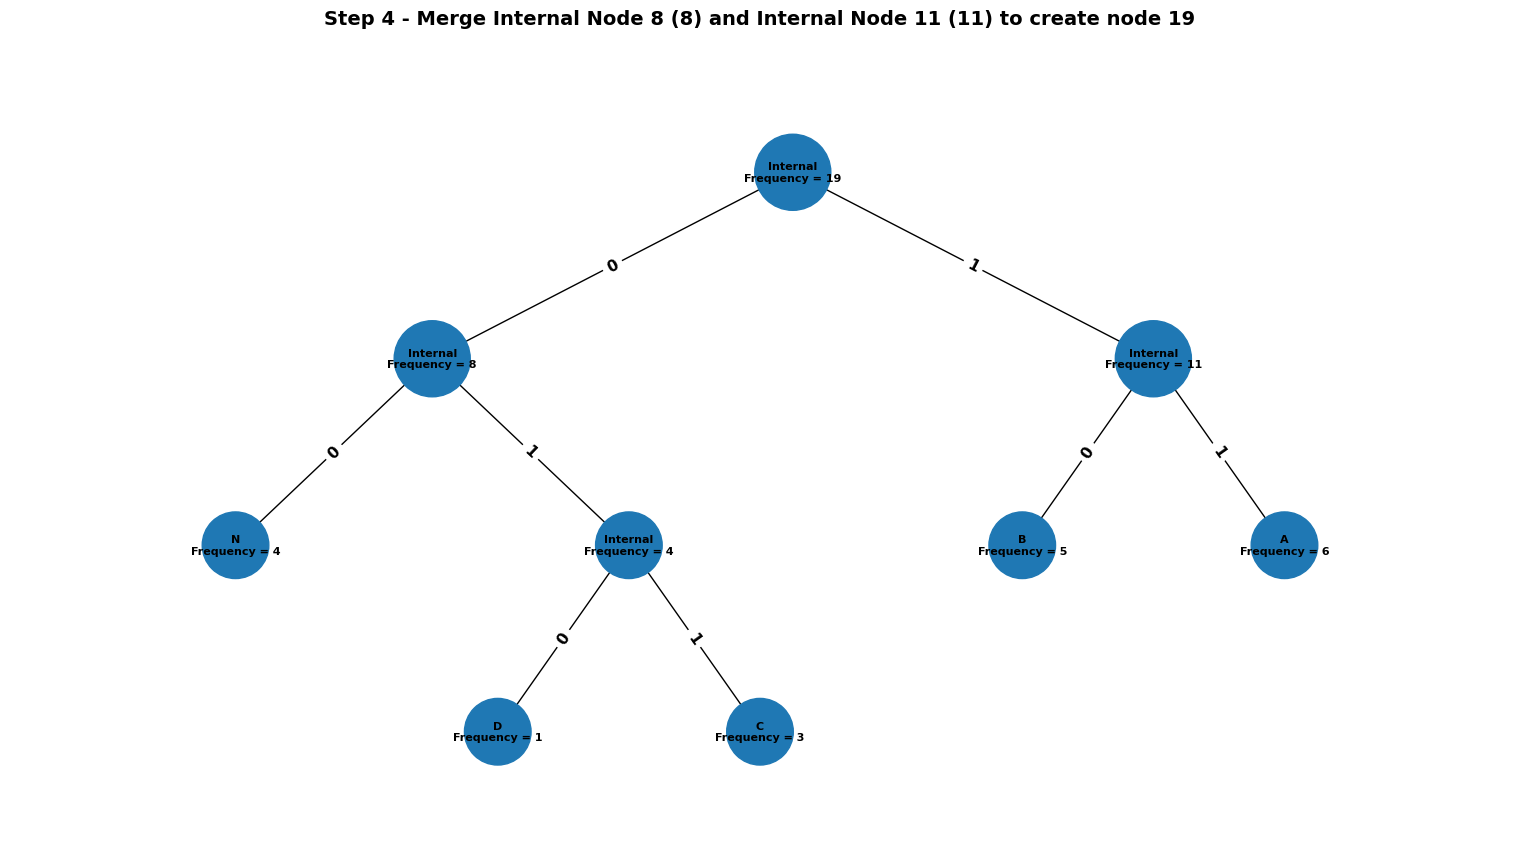

In [50]:
step_directory = RESULTS_DIR / "huffman_steps"
step_directory.mkdir(
    parents=True,
    exist_ok=True
)

tree_sample = "BANANABBCCCBBANDANA"

sample_frequencies = frequency_table(
    tree_sample
)

print("Input text:")
print(tree_sample)

print("\nFrequency table:")
display(
    pd.DataFrame(
        {
            "Symbol": list(sample_frequencies.keys()),
            "Frequency": list(sample_frequencies.values()),
        }
    ).sort_values(
        by=["Frequency", "Symbol"]
    ).reset_index(drop=True)
)


tree_root, construction_steps = (
    build_huffman_tree_with_steps(
        sample_frequencies
    )
)

step_image_paths = []
step_summary_rows = []

for step_information in construction_steps:
    step_number = step_information["step"]

    output_path = (
        step_directory
        / f"huffman_step_{step_number:02d}.png"
    )

    selected_nodes = set()

    if step_information["left"] is not None:
        selected_nodes.add(
            id(step_information["left"])
        )

    if step_information["right"] is not None:
        selected_nodes.add(
            id(step_information["right"])
        )

    if step_information["parent"] is not None:
        selected_nodes.add(
            id(step_information["parent"])
        )

    draw_huffman_forest(
        roots=step_information["roots"],
        title=step_information["title"],
        output_path=output_path,
        selected_nodes=selected_nodes,
    )

    step_image_paths.append(
        output_path
    )

    if step_information["left"] is None:
        left_frequency = None
        right_frequency = None
        merged_frequency = None

    else:
        left_frequency = (
            step_information["left"].frequency
        )

        right_frequency = (
            step_information["right"].frequency
        )

        merged_frequency = (
            step_information["parent"].frequency
        )

    step_summary_rows.append(
        {
            "Step": step_number,
            "Left node frequency": left_frequency,
            "Right node frequency": right_frequency,
            "Merged frequency": merged_frequency,
            "Trees remaining": len(
                step_information["roots"]
            ),
            "Description": step_information["title"],
        }
    )

## Part 5F — Huffman Construction Summary

This table reports the selected nodes and the number of remaining trees after every merge.

In [51]:
steps_summary = pd.DataFrame(
    step_summary_rows
)

display(
    steps_summary
)

steps_summary.to_csv(
    RESULTS_DIR / "huffman_construction_steps.csv",
    index=False,
)

,Step,Left node frequency,Right node frequency,Merged frequency,Trees remaining,Description
0,0,NaN,NaN,NaN,5,Step 0 - Initial frequency nodes
1,1,1.0,3.0,4.0,4,Step 1 - Merge 'D' (1) and 'C' (3) to create n...
2,2,4.0,4.0,8.0,3,Step 2 - Merge 'N' (4) and Internal Node 4 (4)...
3,3,5.0,6.0,11.0,2,Step 3 - Merge 'B' (5) and 'A' (6) to create n...
4,4,8.0,11.0,19.0,1,Step 4 - Merge Internal Node 8 (8) and Interna...


## Part 5G — Animated Huffman Construction

The generated GIF displays all Huffman construction stages in sequence.

Step images saved in: d:\pama\projectHadis\data_compression_huffman_project\results\huffman_steps
Animated GIF saved as: d:\pama\projectHadis\data_compression_huffman_project\results\huffman_steps\huffman_construction_steps.gif


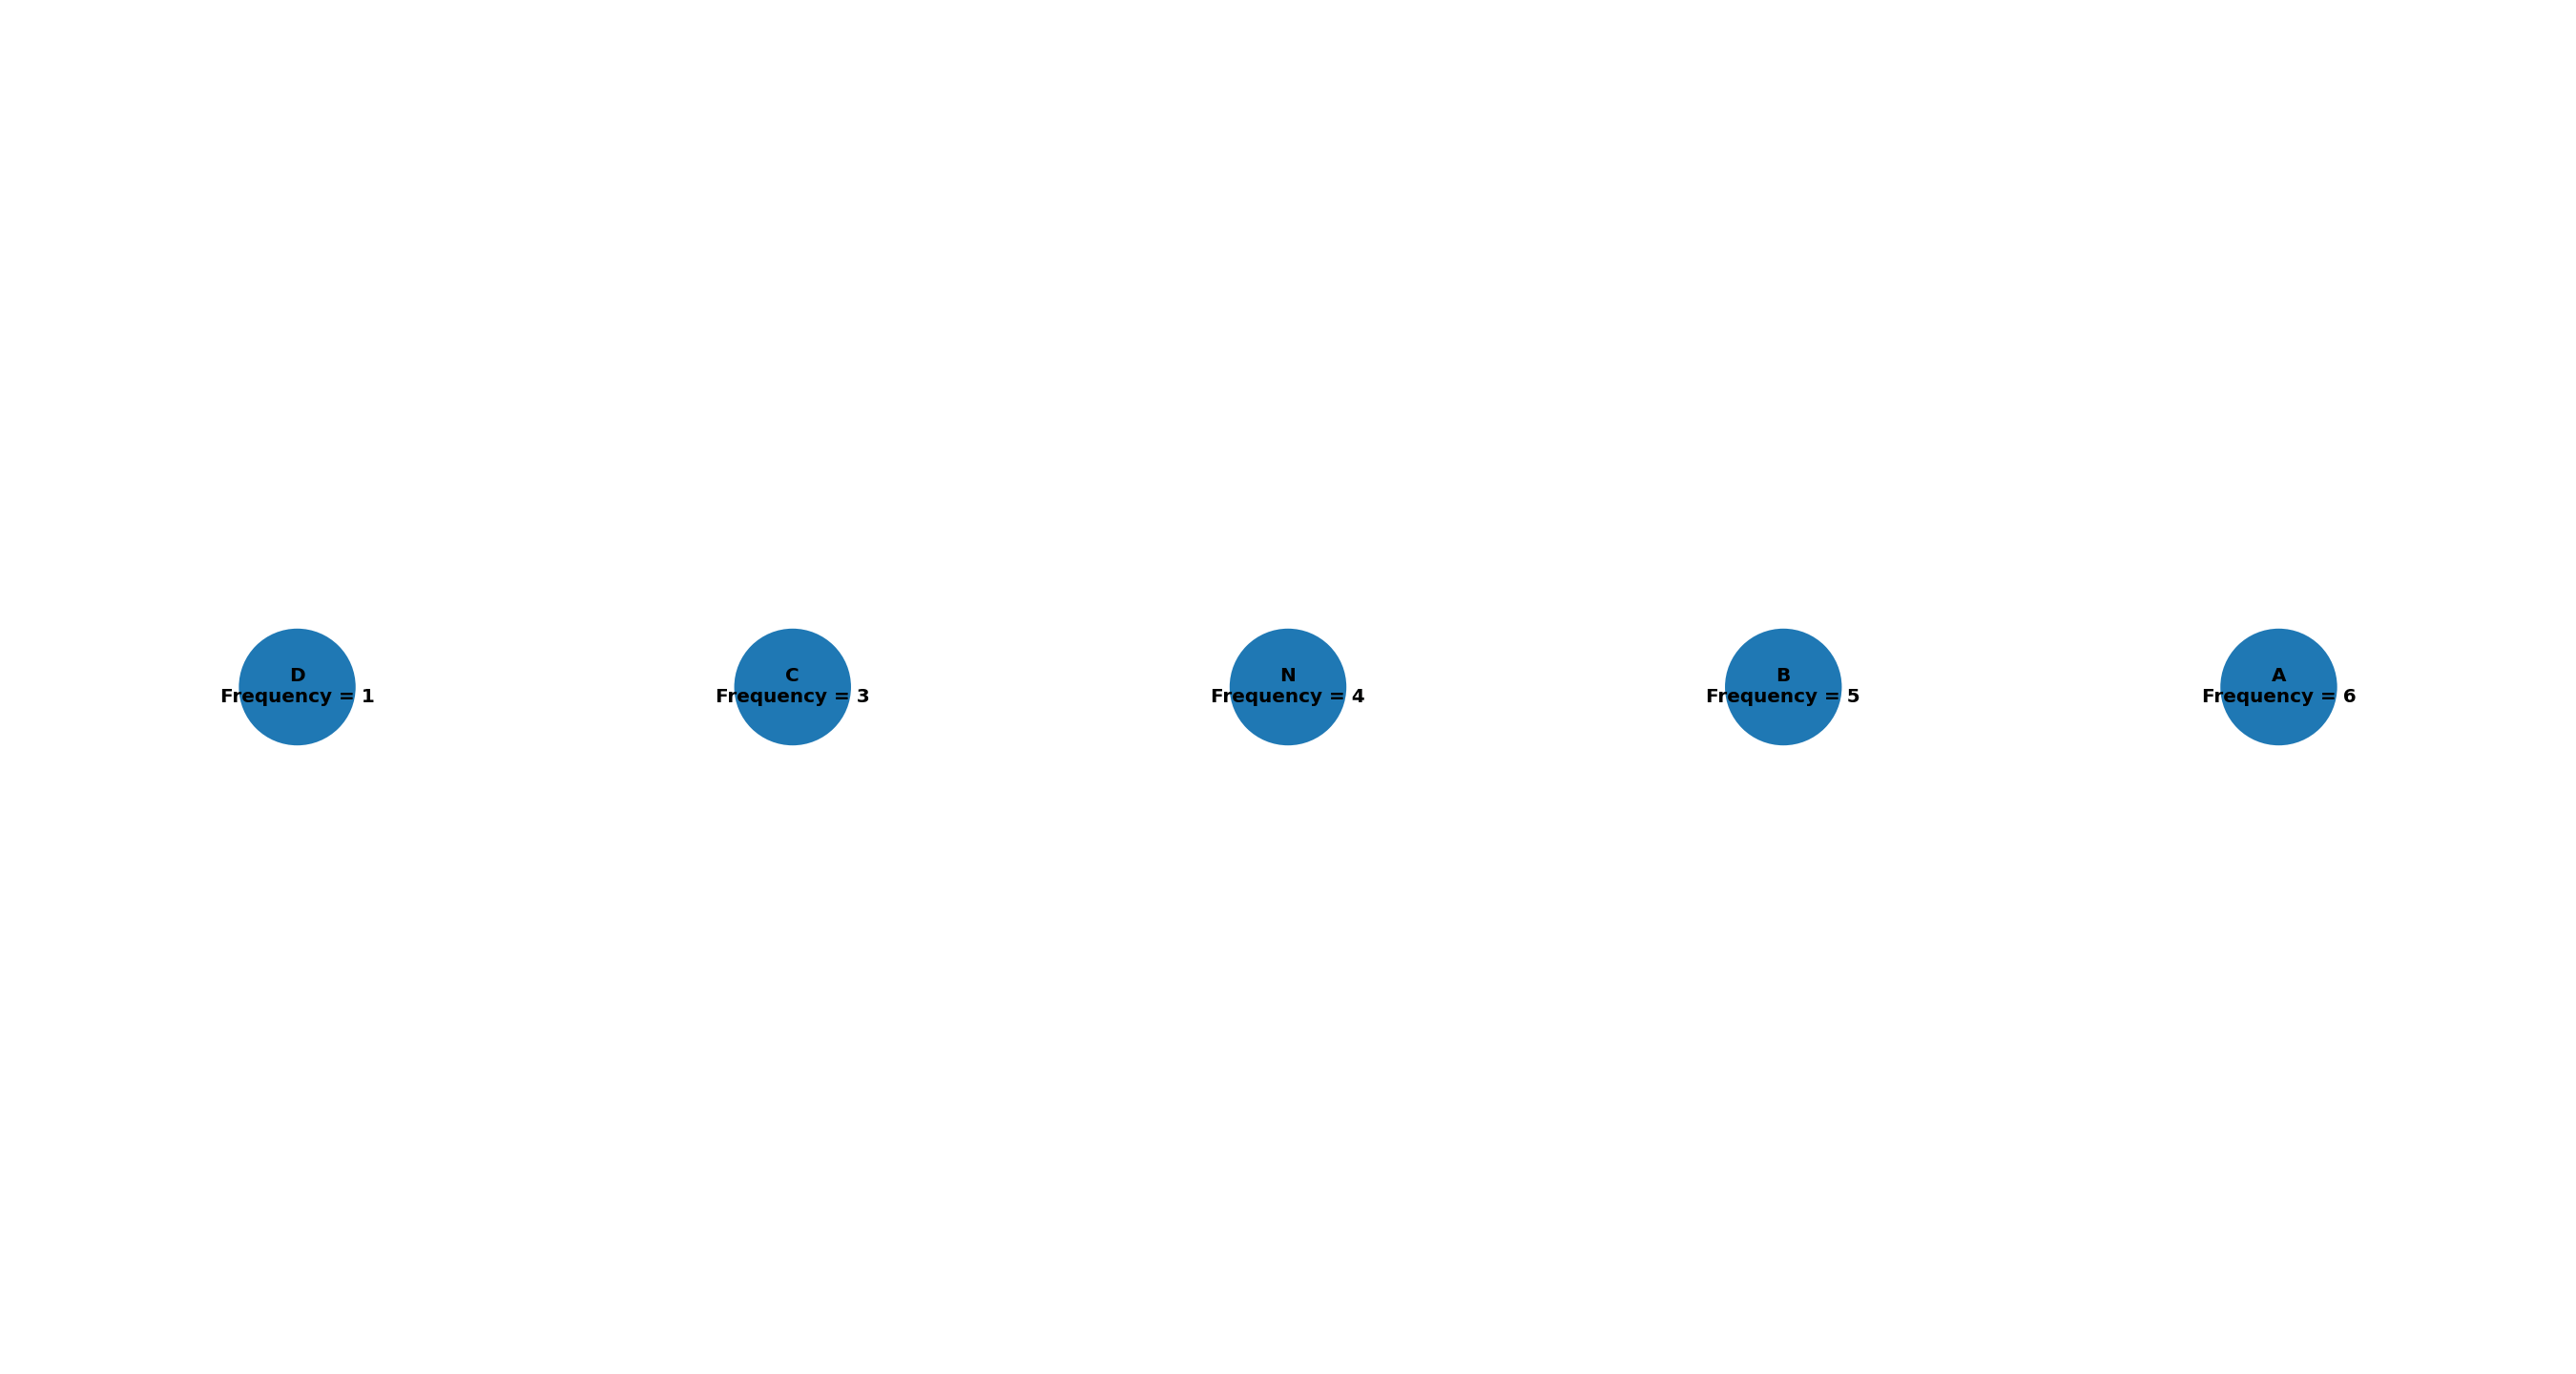

In [52]:
gif_frames = [
    PILImage.open(image_path).convert("RGB")
    for image_path in step_image_paths
]

gif_path = (
    step_directory
    / "huffman_construction_steps.gif"
)

gif_frames[0].save(
    gif_path,
    save_all=True,
    append_images=gif_frames[1:],
    duration=1400,
    loop=0,
)

print(
    f"Step images saved in: {step_directory}"
)

print(
    f"Animated GIF saved as: {gif_path}"
)

display(
    IPythonImage(
        filename=str(gif_path)
    )
)

## Part 6 — Static Huffman File Compression

Compress, restore, verify, and save both UTF-8 files.

In [53]:
static_results = {}

for language, path in text_files.items():
    original = path.read_bytes()

    start = time.perf_counter()
    compressed = compress_bytes(original)
    encode_seconds = time.perf_counter() - start

    start = time.perf_counter()
    restored = decompress_bytes(compressed)
    decode_seconds = time.perf_counter() - start

    assert restored == original

    stem = path.stem
    (RESULTS_DIR / f"{stem}.huf").write_bytes(compressed)
    (RESULTS_DIR / f"{stem}_huffman_restored.txt").write_bytes(restored)

    static_results[language] = {
        "Original bytes": len(original),
        "Compressed bytes": len(compressed),
        "Encode seconds": encode_seconds,
        "Decode seconds": decode_seconds,
    }

pd.DataFrame(static_results).T.round(6)

,Original bytes,Compressed bytes,Encode seconds,Decode seconds
English,33119.0,18636.0,0.029174,0.080913
Persian,51119.0,26793.0,0.032945,0.095047


## Part 7 — LZW Coding

Dictionary coding with fixed 12-bit packed codes.

In [54]:
from __future__ import annotations

import struct
from typing import Dict, List

LZW_MAGIC = b"LZW1"
MAX_CODE = 4095
CODE_WIDTH = 12


def lzw_encode(data: bytes, max_code: int = MAX_CODE) -> List[int]:
    if not data:
        return []

    dictionary: Dict[bytes, int] = {bytes([value]): value for value in range(256)}
    next_code = 256
    current = bytes([data[0]])
    output: List[int] = []

    for value in data[1:]:
        candidate = current + bytes([value])
        if candidate in dictionary:
            current = candidate
        else:
            output.append(dictionary[current])
            if next_code <= max_code:
                dictionary[candidate] = next_code
                next_code += 1
            current = bytes([value])

    output.append(dictionary[current])
    return output


def lzw_decode(codes: List[int], max_code: int = MAX_CODE) -> bytes:
    if not codes:
        return b""

    dictionary: Dict[int, bytes] = {value: bytes([value]) for value in range(256)}
    next_code = 256

    first = codes[0]
    if first not in dictionary:
        raise ValueError("Invalid first LZW code.")

    current = dictionary[first]
    output = bytearray(current)

    for code in codes[1:]:
        if code in dictionary:
            entry = dictionary[code]
        elif code == next_code:
            entry = current + current[:1]
        else:
            raise ValueError(f"Invalid LZW code: {code}")

        output.extend(entry)
        if next_code <= max_code:
            dictionary[next_code] = current + entry[:1]
            next_code += 1
        current = entry

    return bytes(output)


def pack_12bit_codes(codes: List[int]) -> bytes:
    accumulator = 0
    bits_in_accumulator = 0
    payload = bytearray()

    for code in codes:
        if not 0 <= code <= MAX_CODE:
            raise ValueError("A 12-bit LZW code must be between 0 and 4095.")
        accumulator = (accumulator << CODE_WIDTH) | code
        bits_in_accumulator += CODE_WIDTH

        while bits_in_accumulator >= 8:
            bits_in_accumulator -= 8
            payload.append((accumulator >> bits_in_accumulator) & 0xFF)
            accumulator &= (1 << bits_in_accumulator) - 1 if bits_in_accumulator else 0

    if bits_in_accumulator:
        payload.append((accumulator << (8 - bits_in_accumulator)) & 0xFF)

    return bytes(payload)


def unpack_12bit_codes(payload: bytes, code_count: int) -> List[int]:
    codes: List[int] = []
    accumulator = 0
    bits_in_accumulator = 0

    for byte in payload:
        accumulator = (accumulator << 8) | byte
        bits_in_accumulator += 8

        while bits_in_accumulator >= CODE_WIDTH and len(codes) < code_count:
            bits_in_accumulator -= CODE_WIDTH
            codes.append((accumulator >> bits_in_accumulator) & MAX_CODE)
            accumulator &= (1 << bits_in_accumulator) - 1 if bits_in_accumulator else 0

    if len(codes) != code_count:
        raise ValueError("Truncated LZW payload.")
    return codes


def compress_lzw(data: bytes) -> bytes:
    codes = lzw_encode(data)
    payload = pack_12bit_codes(codes)
    return LZW_MAGIC + struct.pack(">QQ", len(data), len(codes)) + payload


def decompress_lzw(blob: bytes) -> bytes:
    if len(blob) < 20 or blob[:4] != LZW_MAGIC:
        raise ValueError("Invalid LZW file.")
    original_size, code_count = struct.unpack_from(">QQ", blob, 4)
    codes = unpack_12bit_codes(blob[20:], code_count)
    decoded = lzw_decode(codes)
    if len(decoded) != original_size:
        raise ValueError("LZW output size mismatch.")
    return decoded

## Part 8 — LZW Verification and File Compression

Round-trip tests and saved LZW artifacts.

In [55]:
lzw_cases = [
    b"",
    b"A",
    b"TOBEORNOTTOBEORTOBEORNOT",
    bytes(range(256)) * 3,
]
for case in lzw_cases:
    assert decompress_lzw(compress_lzw(case)) == case

lzw_results = {}
for language, path in text_files.items():
    original = path.read_bytes()

    start = time.perf_counter()
    compressed = compress_lzw(original)
    encode_seconds = time.perf_counter() - start

    start = time.perf_counter()
    restored = decompress_lzw(compressed)
    decode_seconds = time.perf_counter() - start

    assert restored == original

    stem = path.stem
    (RESULTS_DIR / f"{stem}.lzw").write_bytes(compressed)
    (RESULTS_DIR / f"{stem}_lzw_restored.txt").write_bytes(restored)

    lzw_results[language] = {
        "Original bytes": len(original),
        "Compressed bytes": len(compressed),
        "Encode seconds": encode_seconds,
        "Decode seconds": decode_seconds,
    }

print("All LZW checks passed.")
pd.DataFrame(lzw_results).T.round(6)

All LZW checks passed.


,Original bytes,Compressed bytes,Encode seconds,Decode seconds
English,33119.0,8207.0,0.043059,0.011205
Persian,51119.0,11243.0,0.042190,0.014093


## Part 9 — Single-Pass Adaptive Huffman

The model is updated after every byte and uses an escape symbol for unseen values.

In [56]:
from __future__ import annotations

import struct
from typing import Dict, Tuple

ADAPTIVE_MAGIC = b"AHF1"
ESCAPE = 256


def _decode_one(bits: str, start: int, root) -> Tuple[int, int]:
    if root is None:
        raise ValueError("Adaptive Huffman tree is missing.")

    if root.is_leaf:
        if start >= len(bits) or bits[start] != "0":
            raise ValueError("Invalid single-node adaptive code.")
        return int(root.symbol), start + 1

    node = root
    index = start
    while not node.is_leaf:
        if index >= len(bits):
            raise ValueError("Truncated adaptive Huffman stream.")
        bit = bits[index]
        index += 1
        if bit == "0":
            node = node.left
        elif bit == "1":
            node = node.right
        else:
            raise ValueError("Invalid adaptive Huffman bit.")
        if node is None:
            raise ValueError("Invalid adaptive Huffman path.")

    return int(node.symbol), index


def compress_adaptive(data: bytes) -> bytes:
    counts: Dict[int, int] = {ESCAPE: 1}
    chunks = []

    for value in data:
        root = build_huffman_tree(counts)
        codes = generate_codes(root)

        if value in counts:
            chunks.append(codes[value])
            counts[value] += 1
        else:
            chunks.append(codes[ESCAPE])
            chunks.append(f"{value:08b}")
            counts[value] = 1

    bits = "".join(chunks)
    payload = bits_to_bytes(bits)
    return ADAPTIVE_MAGIC + struct.pack(">QQ", len(data), len(bits)) + payload


def decompress_adaptive(blob: bytes) -> bytes:
    if len(blob) < 20 or blob[:4] != ADAPTIVE_MAGIC:
        raise ValueError("Invalid adaptive Huffman file.")

    original_size, bit_length = struct.unpack_from(">QQ", blob, 4)
    bits = bytes_to_bits(blob[20:], bit_length)
    counts: Dict[int, int] = {ESCAPE: 1}
    output = bytearray()
    index = 0

    while len(output) < original_size:
        root = build_huffman_tree(counts)
        symbol, index = _decode_one(bits, index, root)

        if symbol == ESCAPE:
            if index + 8 > len(bits):
                raise ValueError("Truncated raw symbol in adaptive Huffman stream.")
            value = int(bits[index:index + 8], 2)
            index += 8
            if value in counts:
                raise ValueError("Escape code used for an existing symbol.")
            output.append(value)
            counts[value] = 1
        else:
            if symbol not in counts:
                raise ValueError("Unknown adaptive Huffman symbol.")
            output.append(symbol)
            counts[symbol] += 1

    if index > bit_length:
        raise ValueError("Adaptive Huffman stream overrun.")
    return bytes(output)

## Part 10 — Adaptive Huffman Verification

Correctness tests and an adaptive benchmark on each full sample.

In [57]:
adaptive_cases = [
    b"",
    b"A",
    b"BANANABBCCCBBANDANA",
    bytes(range(64)) * 4,
]
for case in adaptive_cases:
    assert decompress_adaptive(compress_adaptive(case)) == case

adaptive_results = {}
for language, path in text_files.items():
    original = path.read_bytes()

    start = time.perf_counter()
    compressed = compress_adaptive(original)
    encode_seconds = time.perf_counter() - start

    start = time.perf_counter()
    restored = decompress_adaptive(compressed)
    decode_seconds = time.perf_counter() - start

    assert restored == original

    stem = path.stem
    (RESULTS_DIR / f"{stem}.ahf").write_bytes(compressed)
    (RESULTS_DIR / f"{stem}_adaptive_restored.txt").write_bytes(restored)

    adaptive_results[language] = {
        "Original bytes": len(original),
        "Compressed bytes": len(compressed),
        "Encode seconds": encode_seconds,
        "Decode seconds": decode_seconds,
    }

print("All adaptive Huffman checks passed.")
pd.DataFrame(adaptive_results).T.round(6)

All adaptive Huffman checks passed.


,Original bytes,Compressed bytes,Encode seconds,Decode seconds
English,33119.0,18298.0,10.210845,8.761151
Persian,51119.0,26461.0,17.553000,15.632238


## Part 11 — gzip and zlib Baselines

Standard-library compressors provide industrial comparison points.

In [58]:
baseline_results = {}

for language, path in text_files.items():
    original = path.read_bytes()

    gzip_start = time.perf_counter()
    gzip_blob = gzip.compress(original, compresslevel=9)
    gzip_seconds = time.perf_counter() - gzip_start

    zlib_start = time.perf_counter()
    zlib_blob = zlib.compress(original, level=9)
    zlib_seconds = time.perf_counter() - zlib_start

    assert gzip.decompress(gzip_blob) == original
    assert zlib.decompress(zlib_blob) == original

    stem = path.stem
    (RESULTS_DIR / f"{stem}.gz").write_bytes(gzip_blob)
    (RESULTS_DIR / f"{stem}.zlib").write_bytes(zlib_blob)

    baseline_results[language] = {
        "gzip": {"bytes": len(gzip_blob), "seconds": gzip_seconds},
        "zlib": {"bytes": len(zlib_blob), "seconds": zlib_seconds},
    }

baseline_results

{'English': {'gzip': {'bytes': 726, 'seconds': 0.0004501000221353024},
  'zlib': {'bytes': 714, 'seconds': 0.000603899999987334}},
 'Persian': {'gzip': {'bytes': 881, 'seconds': 0.0006955999997444451},
  'zlib': {'bytes': 869, 'seconds': 0.0005675000138580799}}}

## Part 12 — Compression Comparison

Ratios include headers and metadata, so every stored artifact is independently decodable.

In [59]:
comparison_rows = []

for language, path in text_files.items():
    original_size = len(path.read_bytes())
    method_sizes = {
        "Huffman": static_results[language]["Compressed bytes"],
        "LZW": lzw_results[language]["Compressed bytes"],
        "Adaptive Huffman": adaptive_results[language]["Compressed bytes"],
        "gzip": baseline_results[language]["gzip"]["bytes"],
        "zlib": baseline_results[language]["zlib"]["bytes"],
    }

    for method, compressed_size in method_sizes.items():
        comparison_rows.append({
            "Language": language,
            "Method": method,
            "Original bytes": original_size,
            "Compressed bytes": compressed_size,
            "Compression ratio (%)": 100 * compressed_size / original_size,
            "Space saving (%)": 100 * (1 - compressed_size / original_size),
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.round(3))
comparison_df.to_csv(RESULTS_DIR / "compression_comparison.csv", index=False)

,Language,Method,Original bytes,Compressed bytes,Compression ratio (%),Space saving (%)
0,English,Huffman,33119,18636,56.270,43.730
1,English,LZW,33119,8207,24.780,75.220
2,English,Adaptive Huffman,33119,18298,55.249,44.751
3,English,gzip,33119,726,2.192,97.808
4,English,zlib,33119,714,2.156,97.844
5,Persian,Huffman,51119,26793,52.413,47.587
6,Persian,LZW,51119,11243,21.994,78.006
7,Persian,Adaptive Huffman,51119,26461,51.764,48.236
8,Persian,gzip,51119,881,1.723,98.277
9,Persian,zlib,51119,869,1.700,98.300


## Part 13 — Compression Ratio Chart

Lower bars indicate better compression.

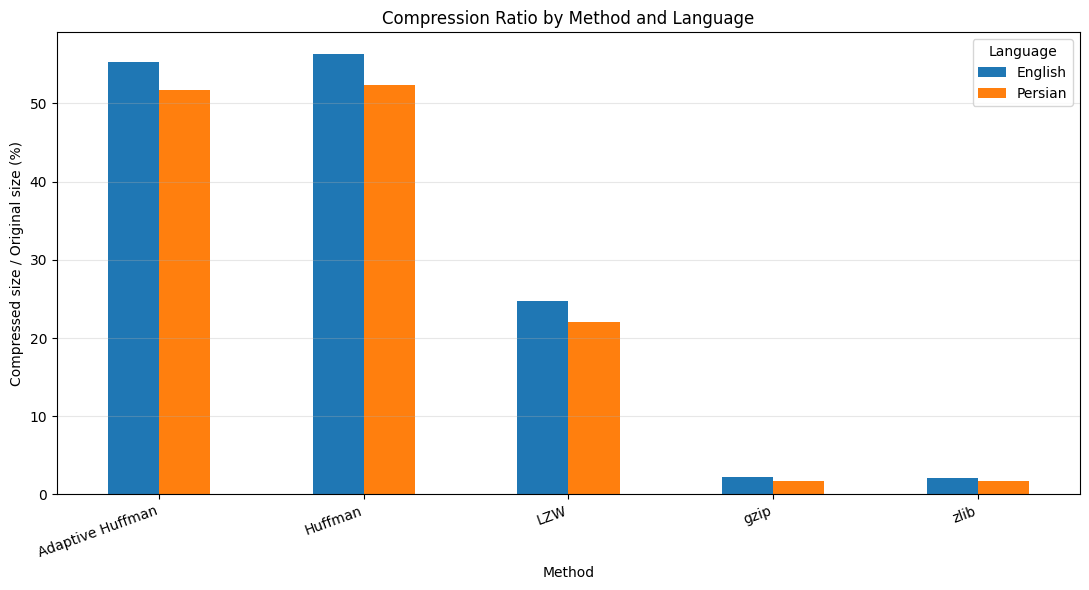

In [60]:
pivot_ratio = comparison_df.pivot(index="Method", columns="Language", values="Compression ratio (%)")
ax = pivot_ratio.plot(kind="bar", figsize=(11, 6))
ax.set_title("Compression Ratio by Method and Language")
ax.set_ylabel("Compressed size / Original size (%)")
ax.set_xlabel("Method")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "compression_ratio_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## Part 14 — Entropy Bound Chart

The measured Huffman average remains between entropy and entropy plus one.

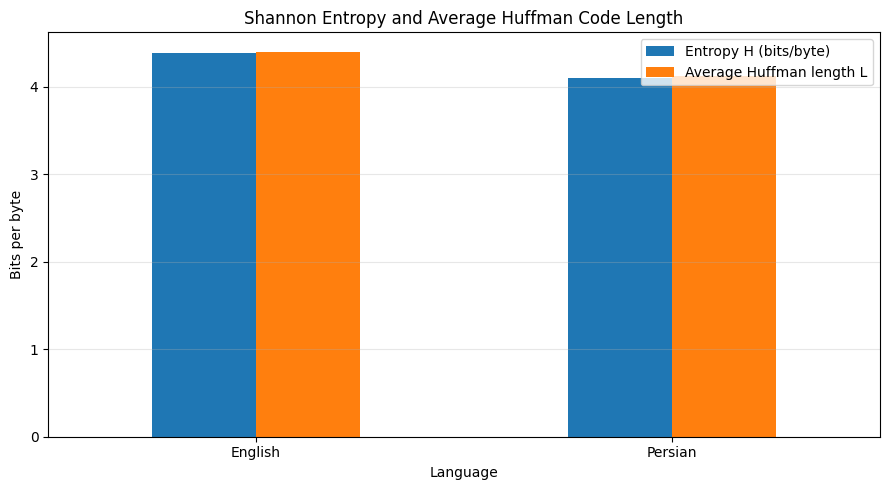

In [61]:
entropy_plot = entropy_df.set_index("Language")[["Entropy H (bits/byte)", "Average Huffman length L"]]
ax = entropy_plot.plot(kind="bar", figsize=(9, 5))
ax.set_title("Shannon Entropy and Average Huffman Code Length")
ax.set_ylabel("Bits per byte")
ax.set_xlabel("Language")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "entropy_vs_average_length.png", dpi=180, bbox_inches="tight")
plt.show()

## Part 15 — Graphical Compression View

Original and Huffman file sizes are shown directly.

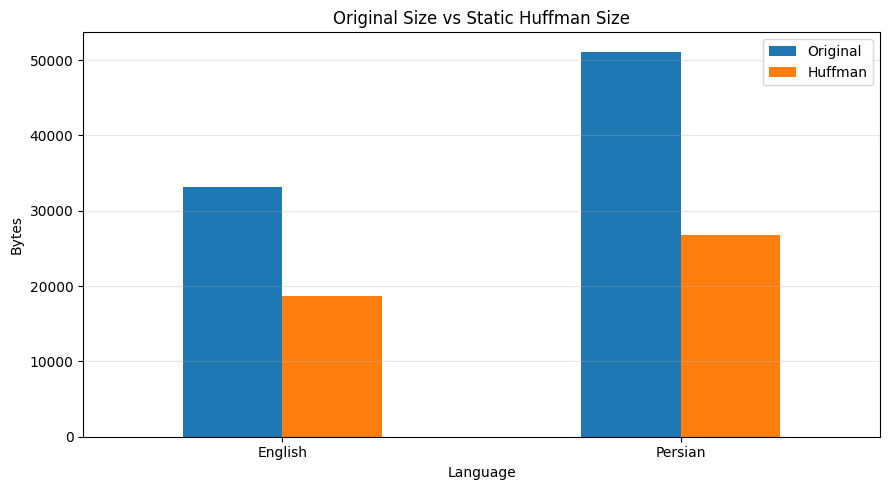

In [62]:
size_rows = []
for language in text_files:
    size_rows.append({
        "Language": language,
        "Original": static_results[language]["Original bytes"],
        "Huffman": static_results[language]["Compressed bytes"],
    })

size_df = pd.DataFrame(size_rows).set_index("Language")
ax = size_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Original Size vs Static Huffman Size")
ax.set_ylabel("Bytes")
ax.set_xlabel("Language")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "original_vs_huffman.png", dpi=180, bbox_inches="tight")
plt.show()

## Part 16 — RLE for a Black-and-White BMP

A simple binary image demonstrates run-length encoding.

In [63]:
from __future__ import annotations


def rle_encode(data: bytes) -> bytes:
    if not data:
        return b""

    output = bytearray()
    current = data[0]
    count = 1

    for value in data[1:]:
        if value == current and count < 255:
            count += 1
        else:
            output.extend((count, current))
            current = value
            count = 1

    output.extend((count, current))
    return bytes(output)


def rle_decode(blob: bytes) -> bytes:
    if len(blob) % 2:
        raise ValueError("RLE data must contain count/value pairs.")

    output = bytearray()
    for index in range(0, len(blob), 2):
        count = blob[index]
        value = blob[index + 1]
        if count == 0:
            raise ValueError("RLE count cannot be zero.")
        output.extend([value] * count)
    return bytes(output)

## Part 17 — BMP RLE Experiment

Generate, encode, decode, verify, and visualize the image.

,Raw pixel bytes,RLE bytes,Compression ratio (%),Space saving (%)
0,65536,1258,1.92,98.08


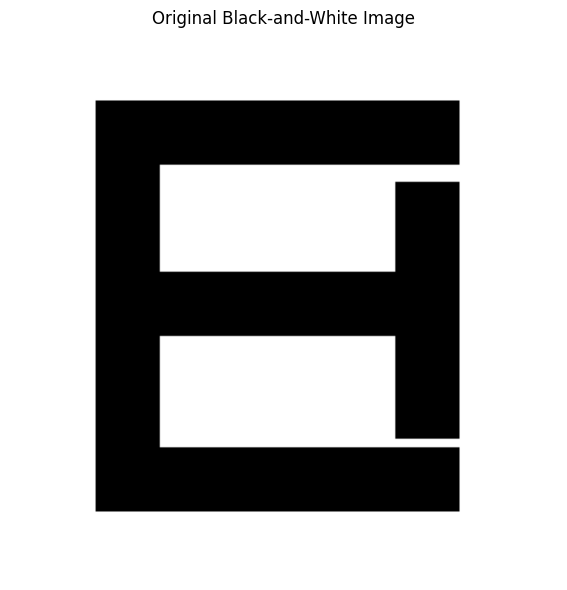

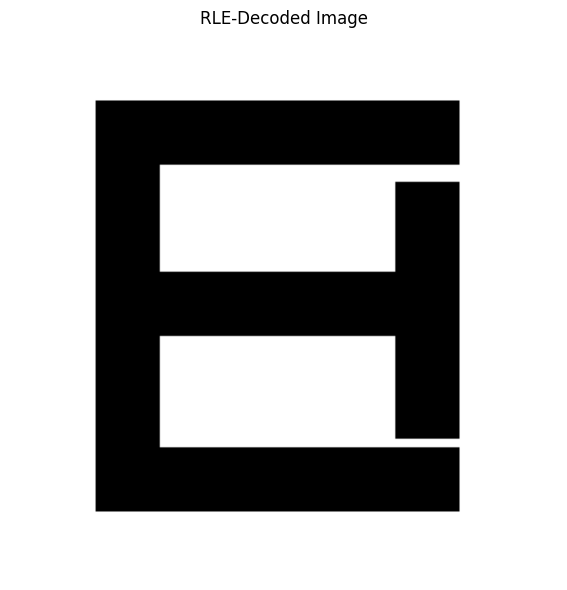

In [64]:
image_array = np.full((256, 256), 255, dtype=np.uint8)
image_array[32:224, 40:70] = 0
image_array[32:62, 40:210] = 0
image_array[112:142, 40:180] = 0
image_array[194:224, 40:210] = 0
image_array[70:190, 180:210] = 0

bmp_path = RESULTS_DIR / "binary_sample.bmp"
Image.fromarray(image_array, mode="L").save(bmp_path)

raw_pixels = image_array.tobytes()
rle_blob = rle_encode(raw_pixels)
restored_pixels = rle_decode(rle_blob)
assert restored_pixels == raw_pixels

(RESULTS_DIR / "binary_sample_pixels.rle").write_bytes(rle_blob)
restored_array = np.frombuffer(restored_pixels, dtype=np.uint8).reshape(image_array.shape)
Image.fromarray(restored_array, mode="L").save(RESULTS_DIR / "binary_sample_rle_restored.bmp")

rle_summary = pd.DataFrame([{
    "Raw pixel bytes": len(raw_pixels),
    "RLE bytes": len(rle_blob),
    "Compression ratio (%)": 100 * len(rle_blob) / len(raw_pixels),
    "Space saving (%)": 100 * (1 - len(rle_blob) / len(raw_pixels)),
}])
display(rle_summary.round(3))
rle_summary.to_csv(RESULTS_DIR / "rle_bmp_summary.csv", index=False)

plt.figure(figsize=(6, 6))
plt.imshow(image_array, cmap="gray", vmin=0, vmax=255)
plt.title("Original Black-and-White Image")
plt.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rle_original_image.png", dpi=180, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(restored_array, cmap="gray", vmin=0, vmax=255)
plt.title("RLE-Decoded Image")
plt.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rle_decoded_image.png", dpi=180, bbox_inches="tight")
plt.show()

## Part 18 — Huffman Image Compression

The black-and-white BMP image is compressed and restored using the static Huffman implementation.

In [66]:
from pathlib import Path
import struct
from PIL import Image


def compress_image_with_huffman(image_path, output_path):
    image_path = Path(image_path)
    output_path = Path(output_path)

    image = Image.open(image_path)

    mode = image.mode
    width, height = image.size
    raw_bytes = image.tobytes()

    compressed_payload = compress_bytes(raw_bytes)

    mode_bytes = mode.encode("utf-8")

    header = (
        struct.pack(
            ">IIH",
            width,
            height,
            len(mode_bytes),
        )
        + mode_bytes
    )

    output_path.write_bytes(
        header + compressed_payload
    )


def decompress_image_with_huffman(
    compressed_path,
    output_path,
):
    compressed_path = Path(compressed_path)
    output_path = Path(output_path)

    blob = compressed_path.read_bytes()

    header_size = struct.calcsize(">IIH")

    width, height, mode_length = struct.unpack_from(
        ">IIH",
        blob,
        0,
    )

    offset = header_size

    mode = blob[
        offset:offset + mode_length
    ].decode("utf-8")

    offset += mode_length

    compressed_payload = blob[offset:]

    raw_bytes = decompress_bytes(
        compressed_payload
    )

    restored_image = Image.frombytes(
        mode,
        (width, height),
        raw_bytes,
    )

    restored_image.save(
        output_path
    )


def image_compression_report(
    image_path,
    compressed_path,
):
    image_path = Path(image_path)
    compressed_path = Path(compressed_path)

    original_size = image_path.stat().st_size
    compressed_size = compressed_path.stat().st_size

    compression_ratio = (
        compressed_size / original_size
    )

    space_saving = (
        1 - compression_ratio
    )

    report = pd.DataFrame(
        [
            {
                "Method": "Huffman",
                "Original size (bytes)": original_size,
                "Compressed size (bytes)": compressed_size,
                "Compression ratio (%)": (
                    compression_ratio * 100
                ),
                "Space saving (%)": (
                    space_saving * 100
                ),
            }
        ]
    )

    display(
        report.round(3)
    )

    report.to_csv(
        RESULTS_DIR
        / "huffman_image_compression_report.csv",
        index=False,
    )

    return report

## Part 18A — Compress and Restore the BMP Image

The image is compressed, reconstructed, verified, and displayed.

In [68]:
original_bmp_path = (
    RESULTS_DIR
    / "binary_sample.bmp"
)

compressed_image_path = (
    RESULTS_DIR
    / "binary_sample_huffman.hufimg"
)

restored_bmp_path = (
    RESULTS_DIR
    / "binary_sample_huffman_restored.bmp"
)


compress_image_with_huffman(
    image_path=original_bmp_path,
    output_path=compressed_image_path,
)


decompress_image_with_huffman(
    compressed_path=compressed_image_path,
    output_path=restored_bmp_path,
)


image_report = image_compression_report(
    image_path=original_bmp_path,
    compressed_path=compressed_image_path,
)


original_image = Image.open(
    original_bmp_path
)

restored_image = Image.open(
    restored_bmp_path
)


assert original_image.mode == restored_image.mode

assert original_image.size == restored_image.size

assert original_image.tobytes() == restored_image.tobytes()


print(
    "Huffman image round-trip verification passed."
)

print(
    f"Compressed image saved as: "
    f"{compressed_image_path}"
)

print(
    f"Restored image saved as: "
    f"{restored_bmp_path}"
)

,Method,Original size (bytes),Compressed size (bytes),Compression ratio (%),Space saving (%)
0,Huffman,66614,8243,12.374,87.626


Huffman image round-trip verification passed.
Compressed image saved as: d:\pama\projectHadis\data_compression_huffman_project\results\binary_sample_huffman.hufimg
Restored image saved as: d:\pama\projectHadis\data_compression_huffman_project\results\binary_sample_huffman_restored.bmp


## Part 18B — Huffman Image Reconstruction

The original and restored images are displayed for visual comparison.

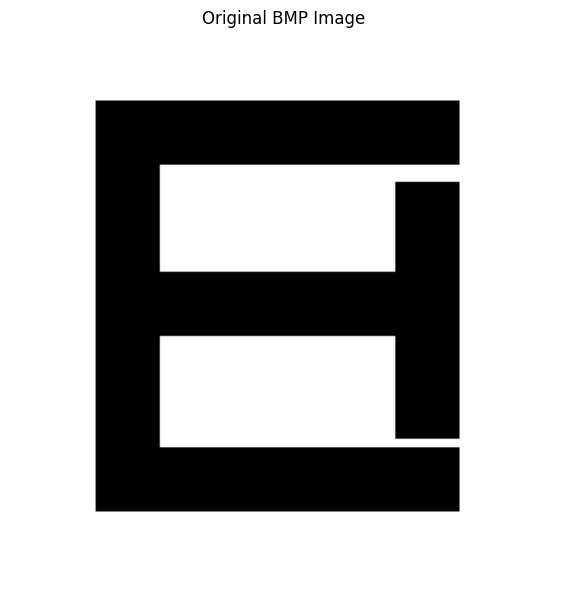

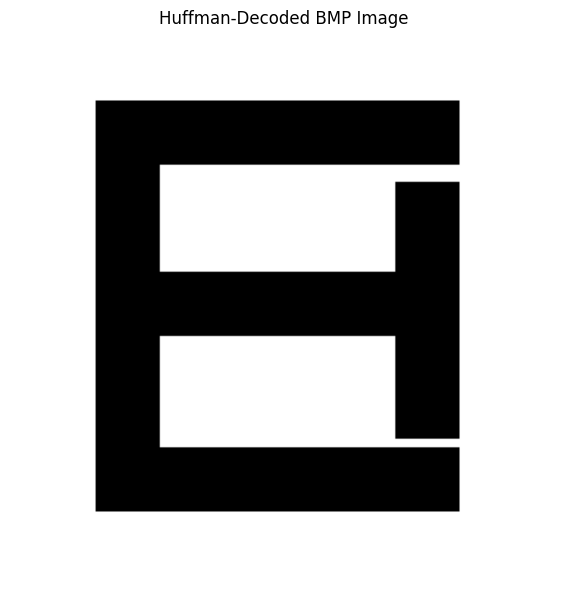

In [69]:
original_array = np.array(
    original_image
)

restored_array = np.array(
    restored_image
)


plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    original_array,
    cmap="gray",
    vmin=0,
    vmax=255,
)

plt.title(
    "Original BMP Image"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "huffman_original_bmp.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    restored_array,
    cmap="gray",
    vmin=0,
    vmax=255,
)

plt.title(
    "Huffman-Decoded BMP Image"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "huffman_restored_bmp.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

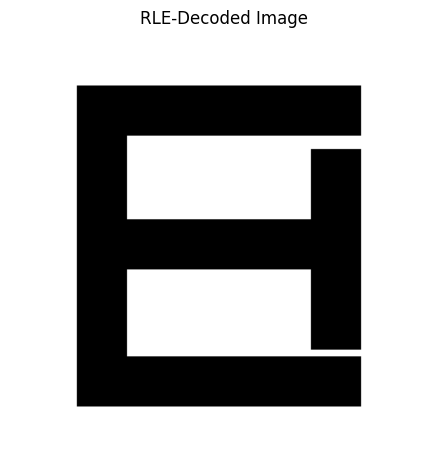

In [70]:
plt.imshow(restored_array, cmap="gray", vmin=0, vmax=255)
plt.title("RLE-Decoded Image")
plt.axis("off")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "rle_decoded_image.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

## Part 19 — Final Validation

All restored files must match the originals byte-for-byte.

In [71]:
validation_rows = []

for language, path in text_files.items():
    original = path.read_bytes()
    stem = path.stem

    restored_files = {
        "Huffman": RESULTS_DIR / f"{stem}_huffman_restored.txt",
        "LZW": RESULTS_DIR / f"{stem}_lzw_restored.txt",
        "Adaptive Huffman": RESULTS_DIR / f"{stem}_adaptive_restored.txt",
    }

    for method, restored_path in restored_files.items():
        restored = restored_path.read_bytes()
        validation_rows.append({
            "Language": language,
            "Method": method,
            "Exact byte match": restored == original,
        })
        assert restored == original

validation_df = pd.DataFrame(validation_rows)
display(validation_df)
validation_df.to_csv(RESULTS_DIR / "round_trip_validation.csv", index=False)

print("PROJECT STATUS: ALL IMPLEMENTATIONS AND VALIDATIONS PASSED")

,Language,Method,Exact byte match
0,English,Huffman,True
1,English,LZW,True
2,English,Adaptive Huffman,True
3,Persian,Huffman,True
4,Persian,LZW,True
5,Persian,Adaptive Huffman,True


PROJECT STATUS: ALL IMPLEMENTATIONS AND VALIDATIONS PASSED
